In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load from Bronze
df = spark.table("customer_churn_project.bronze.online_retail")

print("=" * 60)
print("PHASE 0: DEEP EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic shape
total_rows = df.count()
print(f"\n📊 Total Rows: {total_rows:,}")

# Schema
df.printSchema()

# Sample
print("\n🔍 Sample (5 rows):")
df.show(5, truncate=False)

PHASE 0: DEEP EXPLORATORY DATA ANALYSIS

📊 Total Rows: 541,909
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)


🔍 Sample (5 rows):
+---------+---------+-----------------------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate     |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+----------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |01-12-2010 08:26|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |01-12-2010 08:26|3.39     |17850 

1. NULL ANALYSIS
            InvoiceNo_null_count  StockCode_null_count  Description_null_count  Quantity_null_count  InvoiceDate_null_count  UnitPrice_null_count  CustomerID_null_count  Country_null_count  InvoiceNo_null_pct  StockCode_null_pct  Description_null_pct  Quantity_null_pct  InvoiceDate_null_pct  UnitPrice_null_pct  CustomerID_null_pct  Country_null_pct
Null Count                   0.0                   0.0                  1454.0                  0.0                     0.0                   0.0               135080.0                 0.0                 NaN                 NaN                   NaN                NaN                   NaN                 NaN                  NaN               NaN
Null %                       NaN                   NaN                     NaN                  NaN                     NaN                   NaN                    NaN                 NaN                 0.0                 0.0                  0.27                0.0            

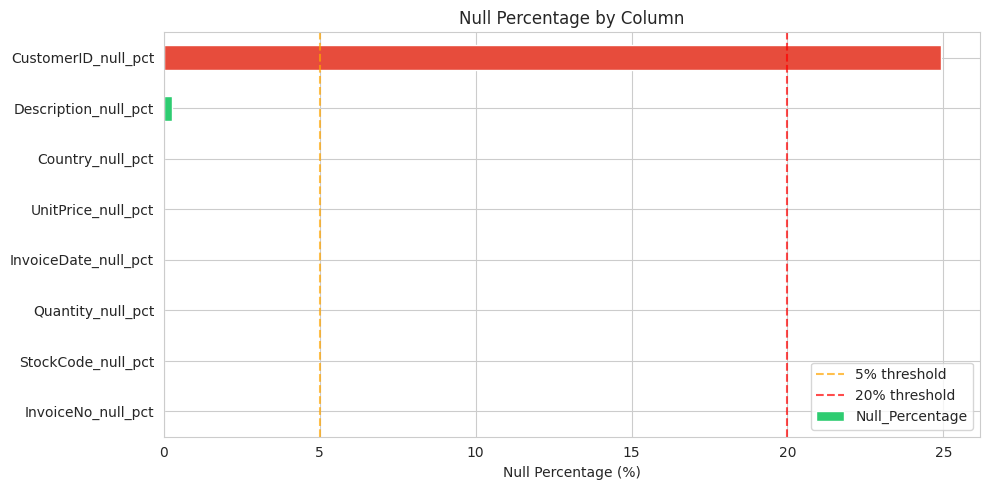


💡 KEY FINDING: CustomerID has ~25% nulls. These rows CANNOT be used for customer-level analysis.


In [0]:
print("=" * 60)
print("1. NULL ANALYSIS")
print("=" * 60)

# Null counts and percentages
null_analysis = df.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c + "_null_count")
    for c in df.columns
]).toPandas()

null_pct = df.select([
    F.round(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)) * 100.0 / F.count("*"), 2).alias(c + "_null_pct")
    for c in df.columns
]).toPandas()

null_df = pd.concat([null_analysis, null_pct])
null_df.index = ["Null Count", "Null %"]

print(null_df.to_string())

# Visualize nulls
fig, ax = plt.subplots(figsize=(10, 5))
null_pct_t = null_pct.T
null_pct_t.columns = ["Null_Percentage"]
null_pct_t = null_pct_t.sort_values("Null_Percentage", ascending=True)

colors = ['#e74c3c' if x > 20 else '#f39c12' if x > 5 else '#2ecc71' for x in null_pct_t["Null_Percentage"]]
null_pct_t["Null_Percentage"].plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel("Null Percentage (%)")
ax.set_title("Null Percentage by Column")
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
ax.legend()
plt.tight_layout()
display(fig)
plt.close()

# Key insight
print("\n💡 KEY FINDING: CustomerID has ~25% nulls. These rows CANNOT be used for customer-level analysis.")

In [0]:
print("=" * 60)
print("2. DUPLICATE ANALYSIS")
print("=" * 60)

# Exact duplicates
exact_dups = df.count() - df.dropDuplicates().count()
print(f"Exact duplicate rows: {exact_dups:,} ({exact_dups * 100.0 / total_rows:.2f}%)")

# Invoice-level duplicates (same InvoiceNo + StockCode + CustomerID)
invoice_dups = df.groupBy("InvoiceNo", "StockCode", "CustomerID").count().filter(F.col("count") > 1)
invoice_dup_count = invoice_dups.count()
print(f"Invoice+StockCode+CustomerID duplicate groups: {invoice_dup_count:,}")

# Show example
if invoice_dup_count > 0:
    print("\nExample duplicate group:")
    example = invoice_dups.orderBy(F.col("count").desc()).limit(1).collect()[0]
    df.filter(
        (F.col("InvoiceNo") == example.InvoiceNo) & 
        (F.col("StockCode") == example.StockCode) & 
        (F.col("CustomerID") == example.CustomerID)
    ).show(truncate=False)

# Cancellation orders (InvoiceNo starts with 'C')
cancelled = df.filter(F.col("InvoiceNo").startswith("C"))
cancel_count = cancelled.count()
print(f"\nCancelled orders (InvoiceNo starts with 'C'): {cancel_count:,} ({cancel_count * 100.0 / total_rows:.2f}%)")

# Show cancellation pattern
print("\nCancellation sample:")
cancelled.select("InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID").show(5, truncate=False)

2. DUPLICATE ANALYSIS
Exact duplicate rows: 5,268 (0.97%)
Invoice+StockCode+CustomerID duplicate groups: 9,694

Example duplicate group:
+---------+---------+------------------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                   |Quantity|InvoiceDate     |UnitPrice|CustomerID|Country       |
+---------+---------+------------------------------+--------+----------------+---------+----------+--------------+
|555524   |22698    |PINK REGENCY TEACUP AND SAUCER|1       |05-06-2011 11:37|2.95     |16923     |United Kingdom|
|555524   |22698    |PINK REGENCY TEACUP AND SAUCER|1       |05-06-2011 11:37|2.95     |16923     |United Kingdom|
|555524   |22698    |PINK REGENCY TEACUP AND SAUCER|1       |05-06-2011 11:37|2.95     |16923     |United Kingdom|
|555524   |22698    |PINK REGENCY TEACUP AND SAUCER|1       |05-06-2011 11:37|2.95     |16923     |United Kingdom|
|555524   |22698    |PINK REGENCY TEACUP AND SAUCER|1     

3. OUTLIER & DISTRIBUTION ANALYSIS
+------------+-------------+------------+-------------+------------+-------------+---------------+----------------+------------+-------------+
|Quantity_min|UnitPrice_min|Quantity_max|UnitPrice_max|Quantity_avg|UnitPrice_avg|Quantity_median|UnitPrice_median|Quantity_std|UnitPrice_std|
+------------+-------------+------------+-------------+------------+-------------+---------------+----------------+------------+-------------+
|-80995      |-11062.06    |80995       |38970.0      |9.55        |4.61         |3              |2.08            |218.08      |96.76        |
+------------+-------------+------------+-------------+------------+-------------+---------------+----------------+------------+-------------+


Rows with Quantity <= 0: 10,624
Rows with UnitPrice <= 0: 2,517

Extreme outliers (Quantity > 10,000): 3
Extreme outliers (UnitPrice > 5,000): 31

Top 5 quantity outliers:
+---------+---------+---------------------------------+--------+---------+--

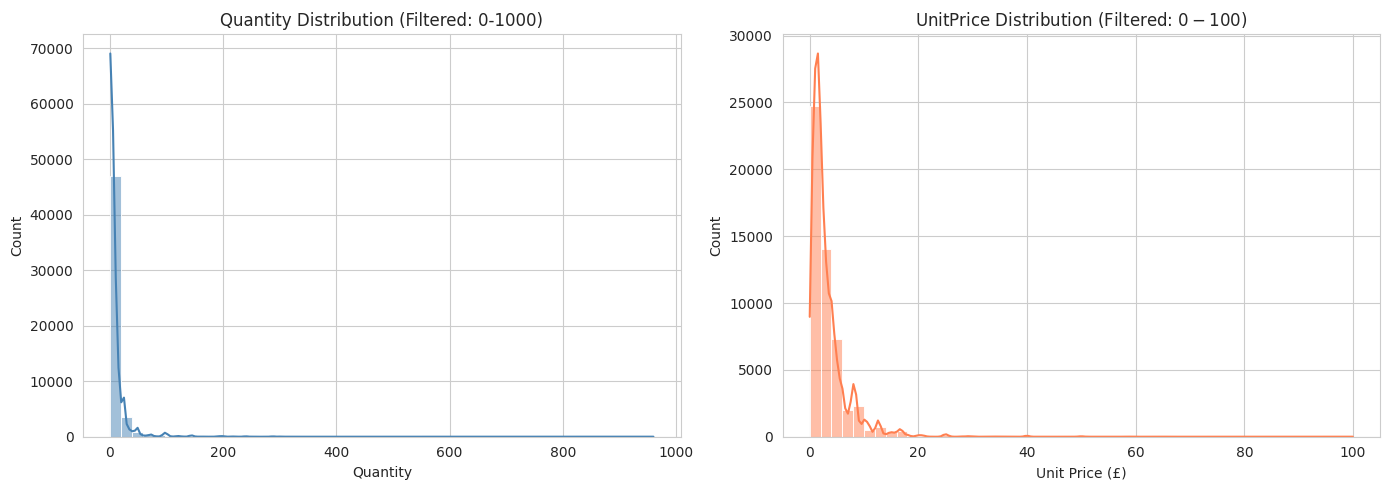

In [0]:
print("=" * 60)
print("3. OUTLIER & DISTRIBUTION ANALYSIS")
print("=" * 60)

# Numeric summary
numeric_cols = ["Quantity", "UnitPrice"]
df.select([F.round(F.min(c), 2).alias(c + "_min") for c in numeric_cols] +
          [F.round(F.max(c), 2).alias(c + "_max") for c in numeric_cols] +
          [F.round(F.avg(c), 2).alias(c + "_avg") for c in numeric_cols] +
          [F.round(F.expr(f"percentile_approx({c}, 0.5)"), 2).alias(c + "_median") for c in numeric_cols] +
          [F.round(F.stddev(c), 2).alias(c + "_std") for c in numeric_cols]).show(truncate=False)

# Negative values
neg_qty = df.filter(F.col("Quantity") <= 0).count()
neg_price = df.filter(F.col("UnitPrice") <= 0).count()
print(f"\nRows with Quantity <= 0: {neg_qty:,}")
print(f"Rows with UnitPrice <= 0: {neg_price:,}")

# Extreme outliers (Quantity > 10,000 or UnitPrice > 5,000)
extreme_qty = df.filter(F.col("Quantity") > 10000).count()
extreme_price = df.filter(F.col("UnitPrice") > 5000).count()
print(f"\nExtreme outliers (Quantity > 10,000): {extreme_qty:,}")
print(f"Extreme outliers (UnitPrice > 5,000): {extreme_price:,}")

if extreme_qty > 0:
    print("\nTop 5 quantity outliers:")
    df.orderBy(F.col("Quantity").desc()).select("InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID").show(5, truncate=False)

# Distribution plots (sample for performance)
sample_df = df.select("Quantity", "UnitPrice").sample(0.1).toPandas()
sample_df = sample_df[(sample_df["Quantity"] > 0) & (sample_df["Quantity"] < 1000) & 
                      (sample_df["UnitPrice"] > 0) & (sample_df["UnitPrice"] < 100)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity distribution
sns.histplot(sample_df["Quantity"], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Quantity Distribution (Filtered: 0-1000)")
axes[0].set_xlabel("Quantity")

# UnitPrice distribution
sns.histplot(sample_df["UnitPrice"], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title("UnitPrice Distribution (Filtered: $0-$100)")
axes[1].set_xlabel("Unit Price (£)")

plt.tight_layout()
display(fig)
plt.close()

4. TEMPORAL & GEOGRAPHIC ANALYSIS
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


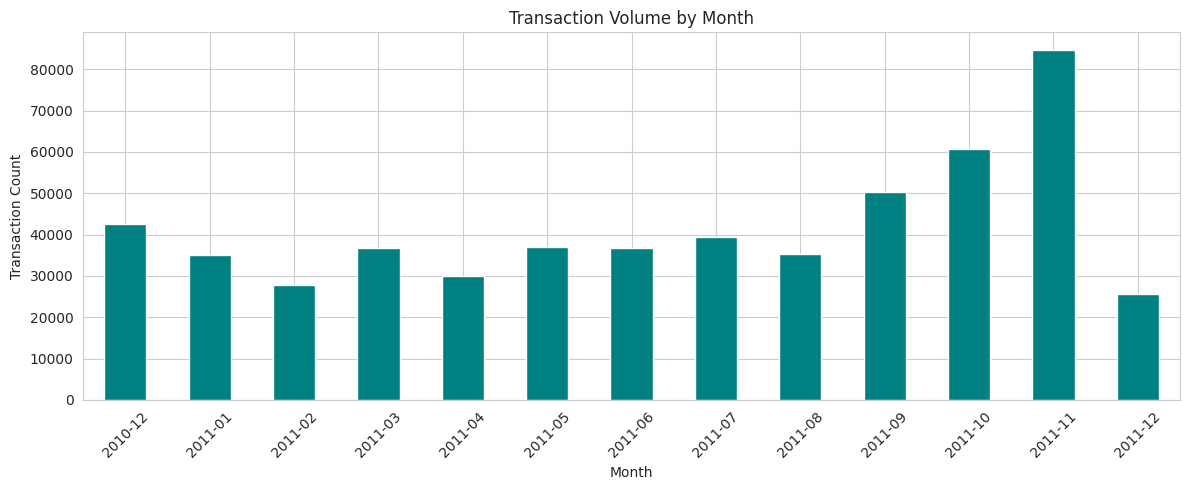

/home/spark-9318ebae-fdd1-4696-a177-75/.ipykernel/317/command-4855478356616968-467961185:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x="count", y="Country", palette="viridis", ax=ax)


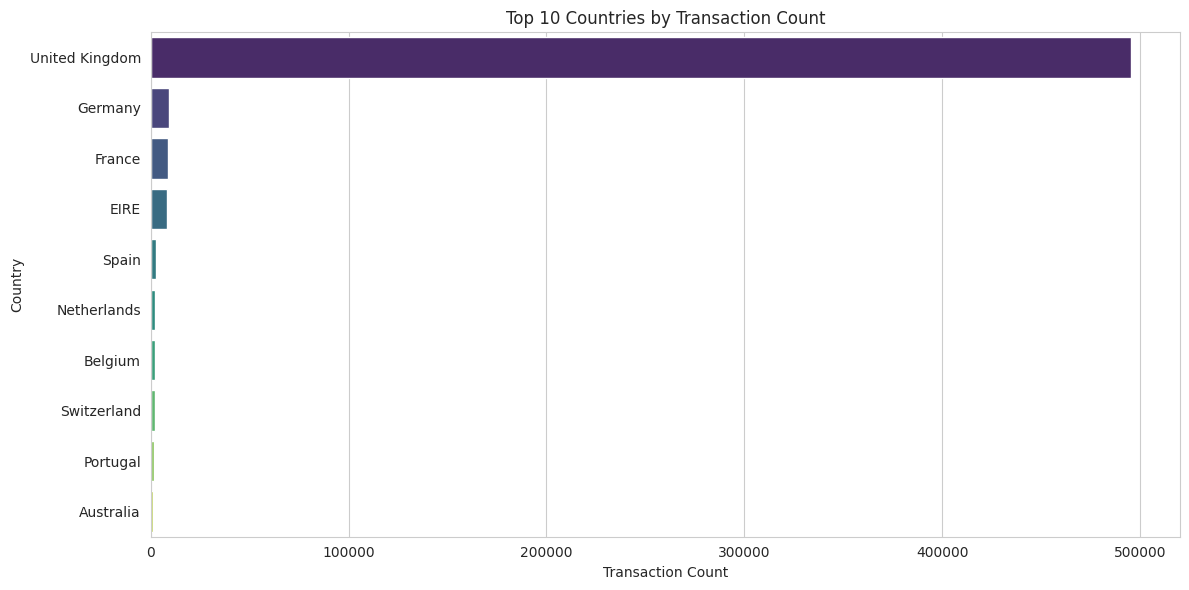


🇬🇧 UK dominates: 495,478 transactions (91.4%)


In [0]:
print("=" * 60)
print("4. TEMPORAL & GEOGRAPHIC ANALYSIS")
print("=" * 60)

# Parse date properly
df_dates = df.withColumn("InvoiceDateParsed", F.try_to_timestamp(F.col("InvoiceDate"), F.lit("dd-MM-yyyy HH:mm")))

# Date range
date_range = df_dates.select(
    F.min("InvoiceDateParsed").alias("min_date"),
    F.max("InvoiceDateParsed").alias("max_date")
).collect()[0]

print(f"Date Range: {date_range.min_date} to {date_range.max_date}")

# Transactions by month
monthly = df_dates.withColumn("YearMonth", F.date_format("InvoiceDateParsed", "yyyy-MM")) \
    .groupBy("YearMonth").count().orderBy("YearMonth").toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(x="YearMonth", y="count", kind="bar", ax=ax, color='teal', legend=False)
ax.set_title("Transaction Volume by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
display(fig)
plt.close()

# Country distribution
country_dist = df.groupBy("Country").count().orderBy(F.col("count").desc()).toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
top_countries = country_dist.head(10)
sns.barplot(data=top_countries, x="count", y="Country", palette="viridis", ax=ax)
ax.set_title("Top 10 Countries by Transaction Count")
ax.set_xlabel("Transaction Count")
plt.tight_layout()
display(fig)
plt.close()

print(f"\n🇬🇧 UK dominates: {country_dist.iloc[0]['count']:,} transactions ({country_dist.iloc[0]['count'] * 100.0 / total_rows:.1f}%)")

5. CUSTOMER-LEVEL ANALYSIS
Valid customers (with CustomerID): 4,338

Customer Spend Statistics:
count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: total_spend, dtype: float64


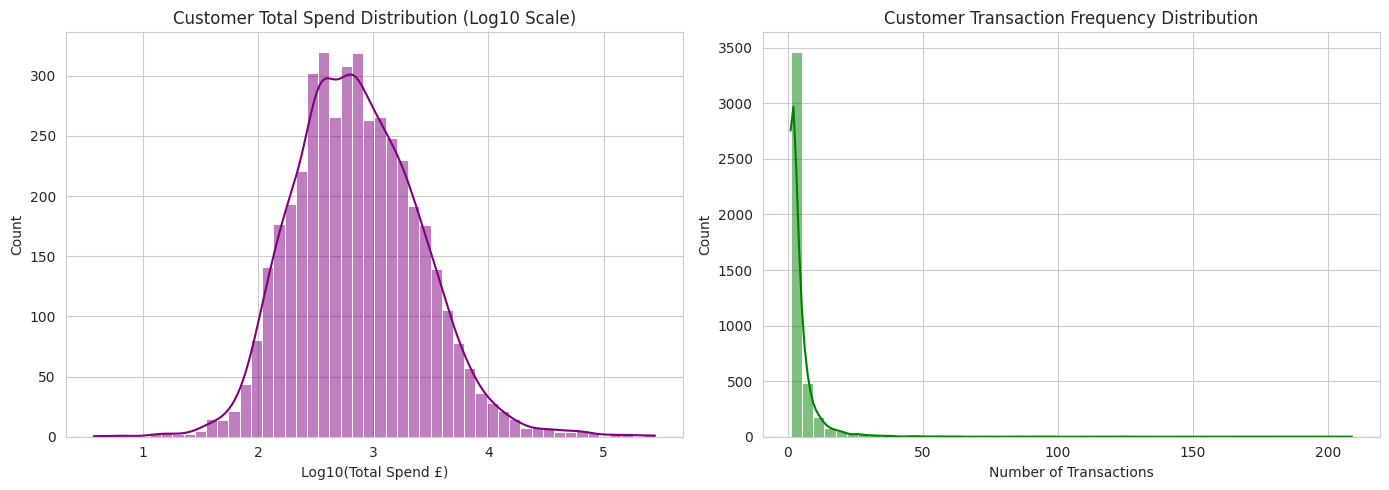


🏆 Top 10 Customers by Total Spend:
 CustomerID  total_spend  transaction_count
      14646    280206.02                 73
      18102    259657.30                 60
      17450    194550.79                 46
      16446    168472.50                  2
      14911    143825.06                201
      12415    124914.53                 21
      14156    117379.63                 55
      17511     91062.38                 31
      16029     81024.84                 63
      12346     77183.60                  1


In [0]:
print("=" * 60)
print("5. CUSTOMER-LEVEL ANALYSIS")
print("=" * 60)

# Clean data for customer metrics
df_clean = df.filter(
    (F.col("CustomerID").isNotNull()) &
    (F.col("Quantity") > 0) &
    (F.col("UnitPrice") > 0)
).withColumn("LineTotal", F.col("Quantity") * F.col("UnitPrice"))

customer_metrics = df_clean.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("transaction_count"),
    F.sum("LineTotal").alias("total_spend"),
    F.sum("Quantity").alias("total_items"),
    F.min("InvoiceDate").alias("first_purchase"),
    F.max("InvoiceDate").alias("last_purchase")
).toPandas()

# Convert to numeric for analysis
customer_metrics["total_spend"] = pd.to_numeric(customer_metrics["total_spend"])
customer_metrics["transaction_count"] = pd.to_numeric(customer_metrics["transaction_count"])

print(f"Valid customers (with CustomerID): {len(customer_metrics):,}")
print(f"\nCustomer Spend Statistics:")
print(customer_metrics["total_spend"].describe())

# Spend distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spend distribution (log scale for visibility)
spend_positive = customer_metrics[customer_metrics["total_spend"] > 0]
sns.histplot(np.log10(spend_positive["total_spend"]), bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title("Customer Total Spend Distribution (Log10 Scale)")
axes[0].set_xlabel("Log10(Total Spend £)")

# Transaction frequency distribution
sns.histplot(customer_metrics["transaction_count"], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title("Customer Transaction Frequency Distribution")
axes[1].set_xlabel("Number of Transactions")

plt.tight_layout()
display(fig)
plt.close()

# Top customers
print("\n🏆 Top 10 Customers by Total Spend:")
top_customers = customer_metrics.nlargest(10, "total_spend")[["CustomerID", "total_spend", "transaction_count"]]
print(top_customers.to_string(index=False))

6. CORRELATION ANALYSIS


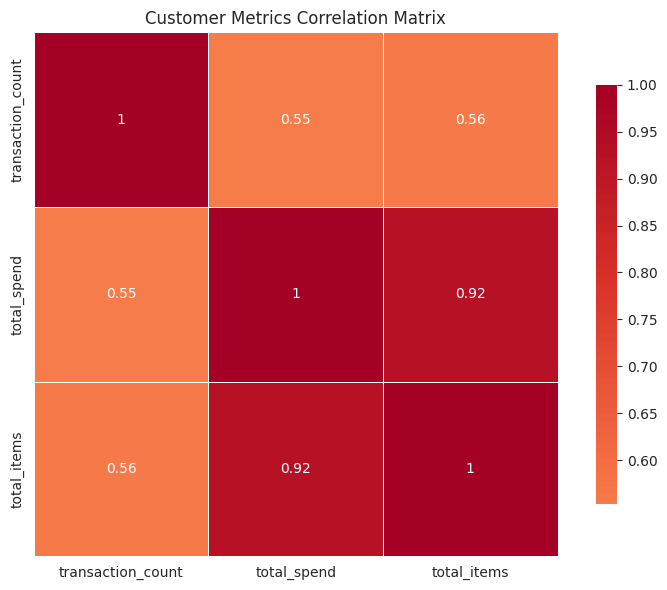


💡 KEY FINDING: Total Spend and Total Items are highly correlated (0.92+).
   This is expected — more items = higher spend. Not a problem, but good to note.


In [0]:
print("=" * 60)
print("6. CORRELATION ANALYSIS")
print("=" * 60)

# Prepare correlation matrix
corr_df = customer_metrics[["transaction_count", "total_spend", "total_items"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="RdYlBu_r", center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Customer Metrics Correlation Matrix")
plt.tight_layout()
display(fig)
plt.close()

print("\n💡 KEY FINDING: Total Spend and Total Items are highly correlated (0.92+).")
print("   This is expected — more items = higher spend. Not a problem, but good to note.")

In [0]:
print("=" * 60)
print("7. DATA QUALITY SCORECARD")
print("=" * 60)

scorecard = {
    "Metric": [
        "Total Rows",
        "Rows with Null CustomerID",
        "Rows with Null Description",
        "Cancelled Orders (Qty < 0 or Invoice 'C')",
        "Rows with UnitPrice <= 0",
        "Exact Duplicate Rows",
        "Valid Customer Records (post-cleaning)",
        "Date Range Span (days)"
    ],
    "Value": [
        f"{total_rows:,}",
        f"{df.filter(F.col('CustomerID').isNull()).count():,} ({df.filter(F.col('CustomerID').isNull()).count() * 100.0 / total_rows:.1f}%)",
        f"{df.filter(F.col('Description').isNull()).count():,} ({df.filter(F.col('Description').isNull()).count() * 100.0 / total_rows:.1f}%)",
        f"{cancel_count:,} ({cancel_count * 100.0 / total_rows:.1f}%)",
        f"{neg_price:,} ({neg_price * 100.0 / total_rows:.2f}%)",
        f"{exact_dups:,} ({exact_dups * 100.0 / total_rows:.2f}%)",
        f"{len(customer_metrics):,}",
        f"{(pd.to_datetime(date_range.max_date) - pd.to_datetime(date_range.min_date)).days}"
    ],
    "Severity": [
        "INFO",
        "HIGH" if df.filter(F.col('CustomerID').isNull()).count() / total_rows > 0.2 else "MEDIUM",
        "LOW",
        "INFO",
        "MEDIUM",
        "LOW",
        "INFO",
        "INFO"
    ]
}

scorecard_df = pd.DataFrame(scorecard)
print(scorecard_df.to_string(index=False))

print("\n" + "=" * 60)
print("EDA COMPLETE. KEY TAKEAWAYS FOR DBT MODELING:")
print("=" * 60)
print("""
1. FILTER: Exclude rows where CustomerID IS NULL (25% of data)
2. FILTER: Exclude cancelled orders (InvoiceNo starts with 'C') and negative quantities
3. FILTER: Exclude rows where UnitPrice <= 0
4. ENGINEER: Create LineTotal = Quantity * UnitPrice
5. NOTE: High correlation between total_spend and total_items (expected)
6. NOTE: UK dominates dataset — consider geographic bias in business recommendations
7. OUTLIERS: Extreme quantities exist (e.g., 74,215 units). Cap or flag in Gold layer.
""")

7. DATA QUALITY SCORECARD
                                   Metric           Value Severity
                               Total Rows         541,909     INFO
                Rows with Null CustomerID 135,080 (24.9%)     HIGH
               Rows with Null Description    1,454 (0.3%)      LOW
Cancelled Orders (Qty < 0 or Invoice 'C')    9,288 (1.7%)     INFO
                 Rows with UnitPrice <= 0   2,517 (0.46%)   MEDIUM
                     Exact Duplicate Rows   5,268 (0.97%)      LOW
   Valid Customer Records (post-cleaning)           4,338     INFO
                   Date Range Span (days)             373     INFO

EDA COMPLETE. KEY TAKEAWAYS FOR DBT MODELING:

1. FILTER: Exclude rows where CustomerID IS NULL (25% of data)
2. FILTER: Exclude cancelled orders (InvoiceNo starts with 'C') and negative quantities
3. FILTER: Exclude rows where UnitPrice <= 0
4. ENGINEER: Create LineTotal = Quantity * UnitPrice
5. NOTE: High correlation between total_spend and total_items (expected)
6